# Classificador de Risco Cardiovascular

## Parte 2 - Fase 2: Diagnóstico Automatizado

Este notebook implementa um classificador de texto que analisa frases com sintomas
cardiovasculares e classifica o nível de risco como **alto risco** ou **baixo risco**.

### Pipeline

1. Carregamento do dataset rotulado (`frases_risco.csv`)
2. Vetorização com TF-IDF (unigramas e bigramas)
3. Treinamento de 3 modelos: Logistic Regression, Decision Tree e Naive Bayes
4. Avaliação com Stratified K-Fold (k=5): precision, recall, F1 e matriz de confusão
5. Teste com frases novas

In [1]:
import csv
from pathlib import Path

import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt

## 1. Carregamento do dataset

O arquivo `frases_risco.csv` contém 160 frases médicas rotuladas como "alto risco"
ou "baixo risco". O dataset inclui ~15-20% de frases intencionalmente ambíguas para
testar a fronteira de decisão dos modelos.

### Critérios de rotulação

| Rótulo | Critério clínico |
|--------|-----------------|
| **alto risco** | Sintomas sugestivos de emergência cardiovascular: dor torácica opressiva/com irradiação, dispneia aguda, síncope, palpitações com instabilidade, sinais de IC descompensada |
| **baixo risco** | Queixas benignas/crônicas estáveis: dor musculoesquelética, cansaço leve, incômodo passageiro, sintomas inespecíficos sem urgência |

In [2]:
CAMINHO_CSV = Path("../data/textuais/frases_risco.csv")

frases = []
rotulos = []

with open(CAMINHO_CSV, encoding="utf-8") as f:
    leitor = csv.DictReader(f)
    for linha in leitor:
        frases.append(linha["frase"])
        rotulos.append(linha["situacao"])

rotulos_np = np.array(rotulos)

print(f"Total de frases: {len(frases)}")
print(f"Alto risco: {sum(1 for r in rotulos if r == 'alto risco')}")
print(f"Baixo risco: {sum(1 for r in rotulos if r == 'baixo risco')}")
print(f"\nExemplos:")
for i in [0, 1, 60, 61]:
    print(f"  [{rotulos[i]:11s}] {frases[i]}")

Total de frases: 160
Alto risco: 81
Baixo risco: 79

Exemplos:
  [alto risco ] sinto uma dor forte no peito que irradia para o braço esquerdo
  [alto risco ] tenho falta de ar intensa que começou de repente há uma hora
  [baixo risco] tenho um desconforto leve no estômago depois de comer muito
  [baixo risco] sinto uma fisgada rápida no peito que passou em segundos


## 2. Vetorização com TF-IDF

O TF-IDF (Term Frequency - Inverse Document Frequency) transforma as frases em vetores
numéricos que os modelos de classificação consomem. A configuração utiliza:

- `ngram_range=(1, 2)`: unigramas e bigramas. Em frases médicas curtas, bigramas como
  "dor peito", "falta ar" e "braço esquerdo" possuem maior poder discriminativo que
  unigramas isolados.
- `min_df=2`: descarta termos que aparecem em menos de 2 documentos (elimina ruído).
- `max_df=0.95`: descarta termos que aparecem em mais de 95% dos documentos (elimina
  stopwords implícitas).

In [3]:
vetorizador = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
)

X = vetorizador.fit_transform(frases)
y = rotulos_np

print(f"Dimensões da matriz TF-IDF: {X.shape}")
print(f"Vocabulário: {len(vetorizador.vocabulary_)} termos")
print(f"\nTop-20 termos com maior IDF (mais discriminativos):")

idfs = vetorizador.idf_
termos = vetorizador.get_feature_names_out()
indices_top = np.argsort(idfs)[::-1][:20]
for idx in indices_top:
    print(f"  {termos[idx]:30s} idf={idfs[idx]:.2f}")

Dimensões da matriz TF-IDF: (160, 379)
Vocabulário: 379 termos

Top-20 termos com maior IDF (mais discriminativos):
  aguda                          idf=4.98
  últimos dias                   idf=4.98
  últimos                        idf=4.98
  ansioso                        idf=4.98
  azia                           idf=4.98
  barriga                        idf=4.98
  barriga que                    idf=4.98
  batimentos                     idf=4.98
  braço que                      idf=4.98
  cabeça leve                    idf=4.98
  calor                          idf=4.98
  cansaço maior                  idf=4.98
  cardíaco                       idf=4.98
  tomar                          idf=4.98
  tomar café                     idf=4.98
  trabalho                       idf=4.98
  três dias                      idf=4.98
  tórax                          idf=4.98
  com cansaço                    idf=4.98
  com inchaço                    idf=4.98


## 3. Treinamento e avaliação dos modelos

### Três modelos para comparação

| Modelo | Razão da escolha |
|--------|-----------------|
| **Logistic Regression** | Baseline linear robusto para classificação binária de texto |
| **Decision Tree** | Modelo interpretável que permite visualizar quais termos o classificador considera decisivos |
| **Naive Bayes (Multinomial)** | Modelo probabilístico clássico para classificação de texto com TF-IDF |

### Estratégia de avaliação

Com um dataset de 160 frases, um train/test split simples (ex: 80/20) produziria um
conjunto de teste com apenas 32 frases — insuficiente para estimativa confiável de
métricas. O Stratified K-Fold (k=5) resolve esse problema: cada fold usa ~128 frases
para treino e ~32 para teste, e a estratificação garante que ambas as classes mantêm
a proporção 50/50 em cada fold.

### Métricas

Em classificação de risco médico, falsos negativos (classificar "alto risco" como
"baixo risco") possuem custo assimétrico — um paciente com emergência cardiovascular
ignorado é mais grave que um paciente de baixo risco encaminhado desnecessariamente.
Por isso, **recall da classe "alto risco"** é a métrica mais crítica. Acurácia sozinha
mascara esse desequilíbrio de custos.

In [4]:
modelos = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42, max_depth=10),
    "Naive Bayes": MultinomialNB(),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

metricas = ["accuracy", "precision_macro", "recall_macro", "f1_macro"]

print("=" * 72)
print("AVALIAÇÃO COM STRATIFIED 5-FOLD CROSS-VALIDATION")
print("=" * 72)

resultados = {}

for nome, modelo in modelos.items():
    scores = cross_validate(
        modelo, X, y, cv=cv, scoring=metricas, return_train_score=False,
    )
    resultados[nome] = scores
    print(f"\n--- {nome} ---")
    print(f"  Acurácia:  {scores['test_accuracy'].mean():.3f} (+/- {scores['test_accuracy'].std():.3f})")
    print(f"  Precision: {scores['test_precision_macro'].mean():.3f} (+/- {scores['test_precision_macro'].std():.3f})")
    print(f"  Recall:    {scores['test_recall_macro'].mean():.3f} (+/- {scores['test_recall_macro'].std():.3f})")
    print(f"  F1-macro:  {scores['test_f1_macro'].mean():.3f} (+/- {scores['test_f1_macro'].std():.3f})")

AVALIAÇÃO COM STRATIFIED 5-FOLD CROSS-VALIDATION

--- Logistic Regression ---
  Acurácia:  0.856 (+/- 0.037)
  Precision: 0.856 (+/- 0.038)
  Recall:    0.856 (+/- 0.037)
  F1-macro:  0.856 (+/- 0.037)

--- Decision Tree ---
  Acurácia:  0.662 (+/- 0.050)
  Precision: 0.670 (+/- 0.055)
  Recall:    0.661 (+/- 0.049)
  F1-macro:  0.658 (+/- 0.049)

--- Naive Bayes ---
  Acurácia:  0.856 (+/- 0.051)
  Precision: 0.857 (+/- 0.051)
  Recall:    0.857 (+/- 0.051)
  F1-macro:  0.856 (+/- 0.051)


## 4. Relatório detalhado e matriz de confusão

Para cada modelo, o pipeline treina com o dataset completo e gera:
- **Classification report**: precision, recall e F1 por classe
- **Matriz de confusão**: visualização dos erros de classificação


Logistic Regression — Classification Report (treino completo)
              precision    recall  f1-score   support

  alto risco       0.97      0.96      0.97        81
 baixo risco       0.96      0.97      0.97        79

    accuracy                           0.97       160
   macro avg       0.97      0.97      0.97       160
weighted avg       0.97      0.97      0.97       160


Decision Tree — Classification Report (treino completo)
              precision    recall  f1-score   support

  alto risco       0.95      0.99      0.97        81
 baixo risco       0.99      0.95      0.97        79

    accuracy                           0.97       160
   macro avg       0.97      0.97      0.97       160
weighted avg       0.97      0.97      0.97       160


Naive Bayes — Classification Report (treino completo)
              precision    recall  f1-score   support

  alto risco       0.97      0.95      0.96        81
 baixo risco       0.95      0.97      0.96        79

    acc

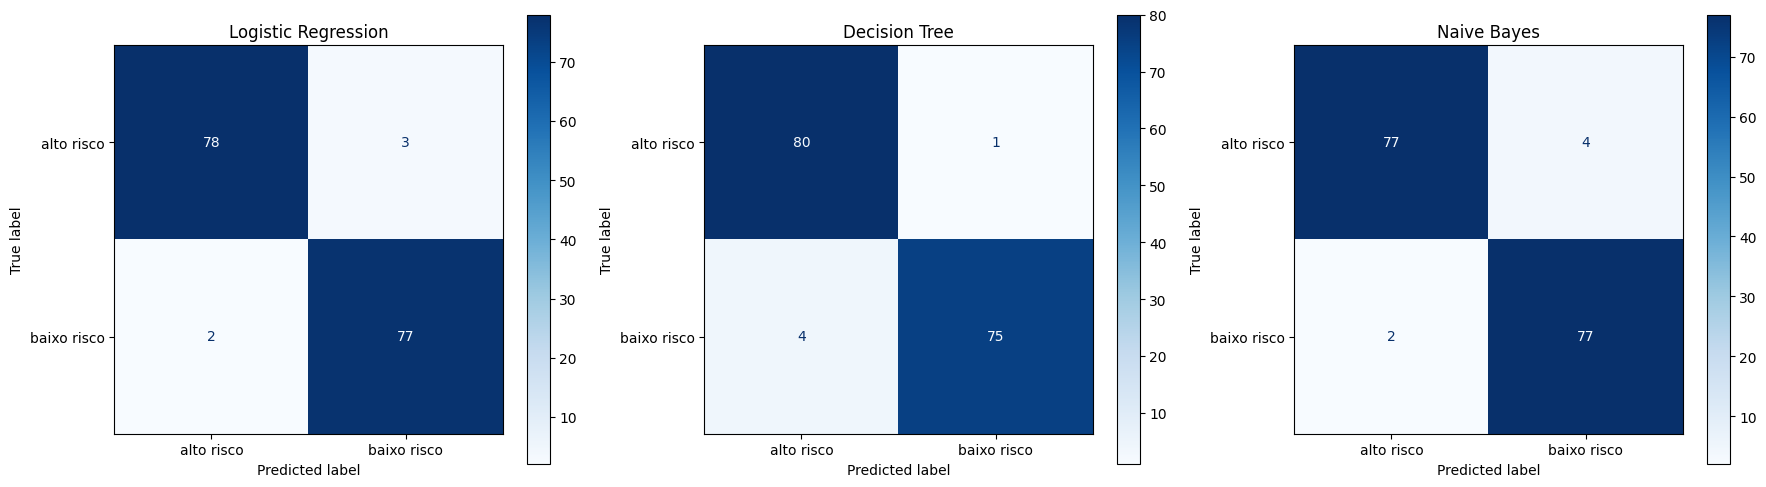


Matrizes de confusão salvas em notebooks/matrizes_confusao.png


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (nome, modelo) in enumerate(modelos.items()):
    modelo.fit(X, y)
    y_pred = modelo.predict(X)

    print(f"\n{'=' * 50}")
    print(f"{nome} — Classification Report (treino completo)")
    print("=" * 50)
    print(classification_report(y, y_pred, target_names=["alto risco", "baixo risco"]))

    cm = confusion_matrix(y, y_pred, labels=["alto risco", "baixo risco"])
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["alto risco", "baixo risco"],
    )
    disp.plot(ax=axes[i], cmap="Blues", values_format="d")
    axes[i].set_title(nome)

plt.tight_layout()
plt.savefig("matrizes_confusao.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nMatrizes de confusão salvas em notebooks/matrizes_confusao.png")

## 5. Termos mais discriminativos

A Logistic Regression atribui coeficientes a cada termo do vocabulário TF-IDF.
Termos com coeficientes positivos altos indicam "alto risco"; negativos altos
indicam "baixo risco".

In [6]:
lr = modelos["Logistic Regression"]
lr.fit(X, y)

coeficientes = lr.coef_[0]
termos = vetorizador.get_feature_names_out()

indices_alto = np.argsort(coeficientes)[::-1][:15]
indices_baixo = np.argsort(coeficientes)[:15]

print("Top-15 termos indicativos de ALTO RISCO:")
print("-" * 45)
for idx in indices_alto:
    print(f"  {termos[idx]:30s} coef={coeficientes[idx]:+.3f}")

print(f"\nTop-15 termos indicativos de BAIXO RISCO:")
print("-" * 45)
for idx in indices_baixo:
    print(f"  {termos[idx]:30s} coef={coeficientes[idx]:+.3f}")

Top-15 termos indicativos de ALTO RISCO:
---------------------------------------------
  leve                           coef=+1.190
  na                             coef=+0.827
  com uma                        coef=+0.805
  uma leve                       coef=+0.785
  quando                         coef=+0.776
  uma                            coef=+0.767
  depois                         coef=+0.746
  tempo                          coef=+0.642
  nas                            coef=+0.547
  aparece                        coef=+0.542
  nas costas                     coef=+0.527
  um                             coef=+0.518
  tenho uma                      coef=+0.517
  incômodo                       coef=+0.504
  do                             coef=+0.501

Top-15 termos indicativos de BAIXO RISCO:
---------------------------------------------
  no peito                       coef=-0.937
  peito                          coef=-0.935
  sinto dor                      coef=-0.892
  tive        

## 6. Teste com frases novas

O teste avalia como cada modelo classifica frases que **não** estavam no dataset de
treinamento, incluindo frases ambíguas que desafiam a fronteira de decisão.

In [7]:
frases_teste = [
    "sinto uma dor forte no peito que irradia para o braço e tenho suor frio",
    "tenho uma dor leve no ombro depois de jogar bola",
    "acordo com falta de ar intensa e preciso sentar para respirar",
    "sinto uma leve queimação no peito após comer pizza",
    "tive um desmaio durante uma corrida e meu pai morreu do coração",
    "estou com dor nas costas que piora quando levanto peso",
    "sinto palpitações fortes com dor no peito e tontura",
    "tenho um cansaço leve no final do dia que melhora com repouso",
    "sinto uma pressão estranha no peito mas não sei se é do estômago",
    "estou com falta de ar e inchaço nas pernas que não melhora",
]

X_teste = vetorizador.transform(frases_teste)

print("CLASSIFICAÇÃO DE FRASES NOVAS")
print("=" * 72)

for frase, x_frase in zip(frases_teste, X_teste):
    print(f"\nFrase: \"{frase}\"")
    for nome, modelo in modelos.items():
        pred = modelo.predict(x_frase)[0]
        if hasattr(modelo, "predict_proba"):
            proba = modelo.predict_proba(x_frase)[0]
            classe_idx = list(modelo.classes_).index(pred)
            confianca = proba[classe_idx]
            print(f"  {nome:25s} -> {pred:11s} (confiança: {confianca:.2f})")
        else:
            print(f"  {nome:25s} -> {pred}")

CLASSIFICAÇÃO DE FRASES NOVAS

Frase: "sinto uma dor forte no peito que irradia para o braço e tenho suor frio"
  Logistic Regression       -> alto risco  (confiança: 0.73)
  Decision Tree             -> alto risco  (confiança: 0.89)
  Naive Bayes               -> alto risco  (confiança: 0.87)

Frase: "tenho uma dor leve no ombro depois de jogar bola"
  Logistic Regression       -> baixo risco (confiança: 0.74)
  Decision Tree             -> baixo risco (confiança: 1.00)
  Naive Bayes               -> baixo risco (confiança: 0.85)

Frase: "acordo com falta de ar intensa e preciso sentar para respirar"
  Logistic Regression       -> alto risco  (confiança: 0.81)
  Decision Tree             -> alto risco  (confiança: 1.00)
  Naive Bayes               -> alto risco  (confiança: 0.91)

Frase: "sinto uma leve queimação no peito após comer pizza"
  Logistic Regression       -> baixo risco (confiança: 0.67)
  Decision Tree             -> baixo risco (confiança: 1.00)
  Naive Bayes            

## 7. Comparação e conclusão

In [8]:
print("RESUMO COMPARATIVO (Stratified 5-Fold CV)")
print("=" * 72)
print(f"{'Modelo':25s} {'Acurácia':>10s} {'Precision':>10s} {'Recall':>10s} {'F1-macro':>10s}")
print("-" * 72)

melhor_f1 = 0
melhor_nome = ""

for nome, scores in resultados.items():
    acc = scores["test_accuracy"].mean()
    prec = scores["test_precision_macro"].mean()
    rec = scores["test_recall_macro"].mean()
    f1 = scores["test_f1_macro"].mean()
    print(f"{nome:25s} {acc:10.3f} {prec:10.3f} {rec:10.3f} {f1:10.3f}")
    if f1 > melhor_f1:
        melhor_f1 = f1
        melhor_nome = nome

print("-" * 72)
print(f"\nMelhor modelo por F1-macro: {melhor_nome} ({melhor_f1:.3f})")
print(f"\nObservações:")
print(f"- O dataset contém 160 frases (81 alto risco, 79 baixo risco)")
print(f"- A avaliação utiliza Stratified 5-Fold para robustez estatística")
print(f"- Bigramas (ngram_range=(1,2)) capturam expressões como 'dor peito' e 'falta ar'")
print(f"- Em contexto clínico, recall da classe 'alto risco' é a métrica mais crítica")

RESUMO COMPARATIVO (Stratified 5-Fold CV)
Modelo                      Acurácia  Precision     Recall   F1-macro
------------------------------------------------------------------------
Logistic Regression            0.856      0.856      0.856      0.856
Decision Tree                  0.662      0.670      0.661      0.658
Naive Bayes                    0.856      0.857      0.857      0.856
------------------------------------------------------------------------

Melhor modelo por F1-macro: Naive Bayes (0.856)

Observações:
- O dataset contém 160 frases (81 alto risco, 79 baixo risco)
- A avaliação utiliza Stratified 5-Fold para robustez estatística
- Bigramas (ngram_range=(1,2)) capturam expressões como 'dor peito' e 'falta ar'
- Em contexto clínico, recall da classe 'alto risco' é a métrica mais crítica
